In [1]:
import sys
import os
from pathlib import Path
# Ensure we are in the project root
project_root = Path(r'D:\DEQ-AD')
if os.getcwd() != str(project_root):
    os.chdir(project_root)
sys.path.append(str(project_root))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
import json
plt.style.use('ggplot')


==================================================
## SECTION 1 — TITLE
==================================================

# DEQ-AD: Final Experimental Results

**Deep Equilibrium Network for Alzheimer’s Disease Classification from Structural MRI**

- **Dataset:** OASIS-1
- **Subjects:** 235
- **Primary task:** CDR=0 vs CDR>0
- **Secondary task:** CDR severity prediction
- **Architecture:** Lightweight 3D Encoder + Deep Equilibrium Layer
- **Seeds:** 42, 123, 2026


==================================================
## SECTION 2 — RESEARCH QUESTION
==================================================

*"Can an equilibrium-based neural representation learn clinically meaningful patterns from structural MRI for Alzheimer’s classification and cognitive-severity prediction?"*

MRI -> 3D encoder -> equilibrium representation -> classification/CDR heads


==================================================
## SECTION 3 — DATASET SUMMARY
==================================================

Total OASIS-1 labelled subjects: 235

| Split | Count |
|---|---|
| Train | 164 |
| Validation | 35 |
| Test | 36 |

| Class | Count |
|---|---|
| Control | 135 |
| Impaired | 100 |

| CDR | Count |
|---|---|
| 0.0 | 135 |
| 0.5 | 70 |
| 1.0 | 28 |
| 2.0 | 2 |


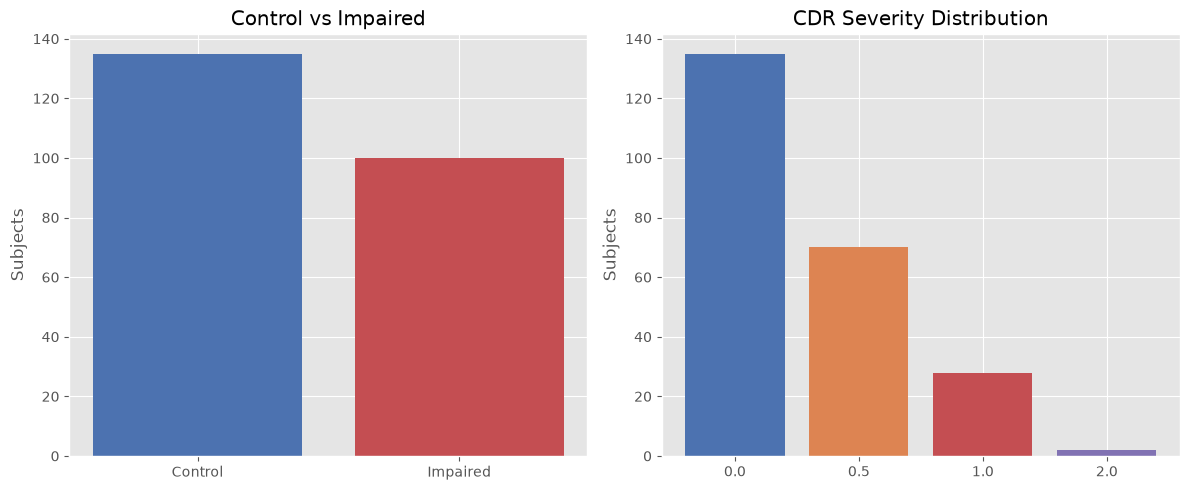

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

classes = ['Control', 'Impaired']
counts = [135, 100]
ax1.bar(classes, counts, color=['#4C72B0', '#C44E52'])
ax1.set_title('Control vs Impaired')
ax1.set_ylabel('Subjects')

cdrs = ['0.0', '0.5', '1.0', '2.0']
cdr_counts = [135, 70, 28, 2]
ax2.bar(cdrs, cdr_counts, color=['#4C72B0', '#DD8452', '#C44E52', '#8172B3'])
ax2.set_title('CDR Severity Distribution')
ax2.set_ylabel('Subjects')

plt.tight_layout()
plt.show()


==================================================
## SECTION 4 — MODEL ARCHITECTURE
==================================================


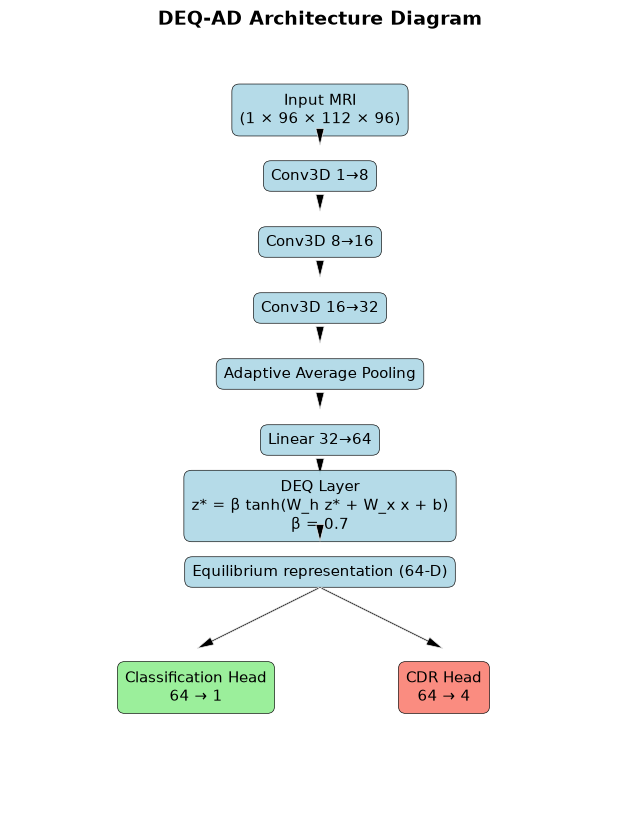

In [3]:
fig, ax = plt.subplots(figsize=(8, 10))

boxes = [
    "Input MRI\n(1 × 96 × 112 × 96)",
    "Conv3D 1→8",
    "Conv3D 8→16",
    "Conv3D 16→32",
    "Adaptive Average Pooling",
    "Linear 32→64",
    "DEQ Layer\nz* = β tanh(W_h z* + W_x x + b)\nβ = 0.7",
    "Equilibrium representation (64-D)"
]

y_pos = np.linspace(0.9, 0.3, len(boxes))

for i, (text, y) in enumerate(zip(boxes, y_pos)):
    ax.text(0.5, y, text, ha='center', va='center', 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='black', alpha=0.9),
            fontsize=11)
    if i < len(boxes) - 1:
        ax.annotate('', xy=(0.5, y_pos[i+1]+0.04), xytext=(0.5, y-0.04), 
                    arrowprops=dict(facecolor='black', shrink=0.01, width=1, headwidth=6))

# Split heads
ax.text(0.3, 0.15, "Classification Head\n64 → 1", ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', edgecolor='black', alpha=0.9),
        fontsize=11)
ax.text(0.7, 0.15, "CDR Head\n64 → 4", ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='salmon', edgecolor='black', alpha=0.9),
        fontsize=11)

ax.annotate('', xy=(0.3, 0.2), xytext=(0.5, 0.28),
            arrowprops=dict(facecolor='black', shrink=0.01, width=1, headwidth=6))
ax.annotate('', xy=(0.7, 0.2), xytext=(0.5, 0.28),
            arrowprops=dict(facecolor='black', shrink=0.01, width=1, headwidth=6))

ax.axis('off')
ax.set_title("DEQ-AD Architecture Diagram", fontsize=14, fontweight='bold')
plt.show()


==================================================
## SECTION 5 — WHY DEQ?
==================================================

**Traditional network:**
Layer 1 → Layer 2 → Layer 3 → ... → Layer N

**DEQ:**
Input → equilibrium transformation → stable representation

$$ z^* = f_\theta(z^*, x) $$

Actual implementation equation:
$$ z^* = \beta \tanh(W_h z^* + W_x x + b) $$

The model does not explicitly unroll a fixed number of hidden layers. Instead, it solves for a stable equilibrium representation and trains it using implicit differentiation.


==================================================
## SECTION 6 — FINAL EXPERIMENTAL PROTOCOL
==================================================

| Parameter | Value |
|---|---|
| Beta | 0.7 |
| Seeds | 42, 123, 2026 |
| Batch size | 2 |
| Optimizer | AdamW |
| Learning rate | 1e-4 |
| Weight decay | 1e-4 |
| Epochs | 20 |
| Early stopping | 5 epochs |
| Checkpoint criterion | Validation ROC-AUC |
| Threshold selection | Validation F1 |
| Final threshold | 0.42 |

**The test set was used only once for final evaluation and was not used for checkpoint selection or threshold tuning.**


==================================================
## SECTION 7 — MULTI-SEED RESULTS
==================================================


In [4]:
results_path = project_root / 'results' / 'final' / 'final_seed_comparison.csv'
df = pd.read_csv(results_path)

display_df = df[['seed', 'test_roc_auc', 'test_f1', 'test_accuracy', 'test_sensitivity', 'test_specificity']].copy()
display_df.columns = ['Seed', 'Test AUC', 'F1', 'Accuracy', 'Sensitivity', 'Specificity']

mean_row = display_df.mean()
std_row = display_df.std()
mean_str = [f"{m:.4f} ± {s:.4f}" if isinstance(m, float) else "Mean ± SD" for m, s in zip(mean_row, std_row)]
display_df.loc['Mean ± SD'] = mean_str
display(display_df)


,Seed,Test AUC,F1,Accuracy,Sensitivity,Specificity
0,42,0.873016,0.75,0.777778,0.8,0.761905
1,123,0.888889,0.588235,0.416667,1.0,0.0
2,2026,0.885714,0.717949,0.694444,0.933333,0.52381
Mean ± SD,730.3333 ± 1122.8109,0.8825 ± 0.0084,0.6854 ± 0.0857,0.6296 ± 0.1891,0.9111 ± 0.1018,0.4286 ± 0.3898


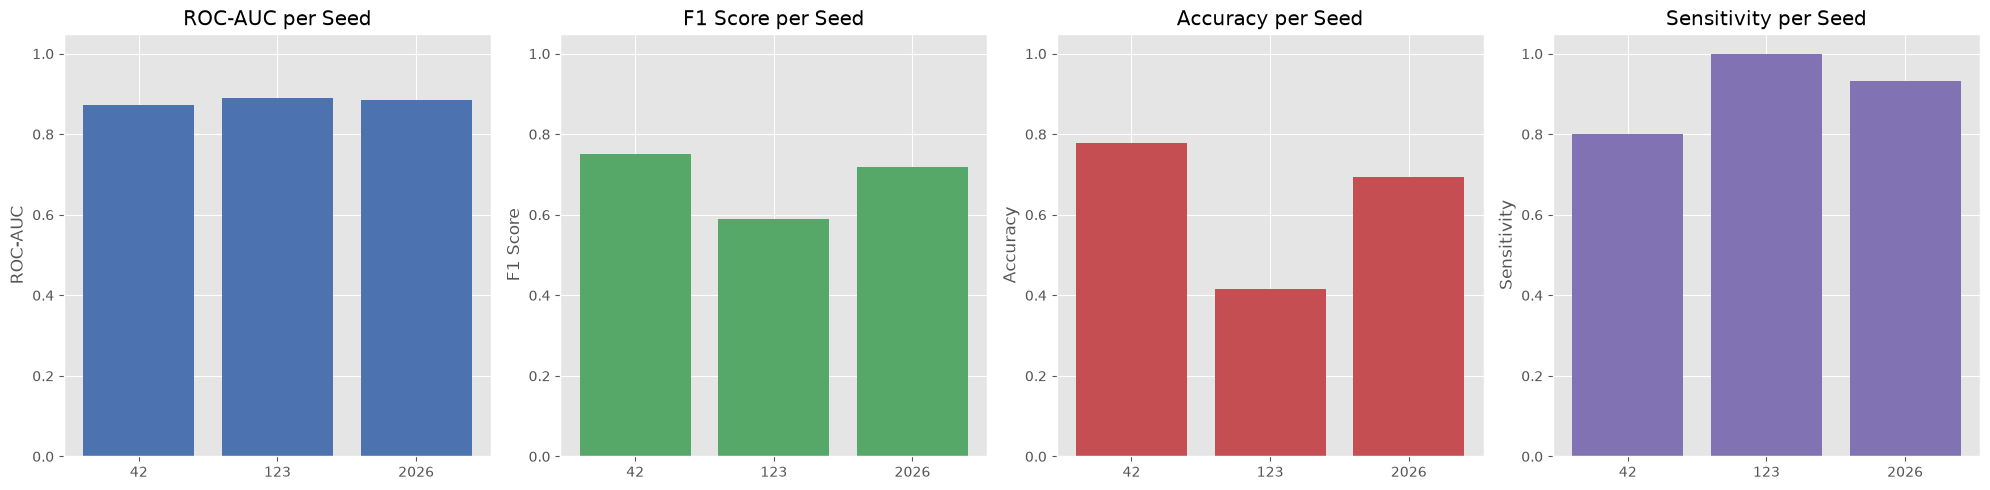

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = ['test_roc_auc', 'test_f1', 'test_accuracy', 'test_sensitivity']
titles = ['ROC-AUC', 'F1 Score', 'Accuracy', 'Sensitivity']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    axes[i].bar([str(s) for s in df['seed']], df[metric], color=color)
    axes[i].set_title(f"{title} per Seed")
    axes[i].set_ylim(0, 1.05)
    axes[i].set_ylabel(title)

plt.tight_layout()
plt.show()


==================================================
## SECTION 8 — MAIN RESULT
==================================================

<div style="border: 2px solid #4C72B0; padding: 20px; text-align: center; background-color: #f8f9fa; border-radius: 10px;">
  <h2 style="color: #4C72B0; margin-top: 0;">FINAL RESULT</h2>
  <h1 style="font-size: 3em; margin: 10px 0;">ROC-AUC</h1>
  <h1 style="font-size: 4em; color: #C44E52; margin: 0;">0.8825 ± 0.0084</h1>
  <p style="font-size: 1.2em; font-style: italic;">Across 3 independent random seeds</p>
</div>

**Additional Metrics:**
- **F1:** 0.6854 ± 0.0857
- **Accuracy:** 0.6296 ± 0.1891
- **DEQ convergence:** 100%
- **Average equilibrium iterations:** 10.35 ± 0.36


==================================================
## SECTION 9 — ROC CURVES
==================================================


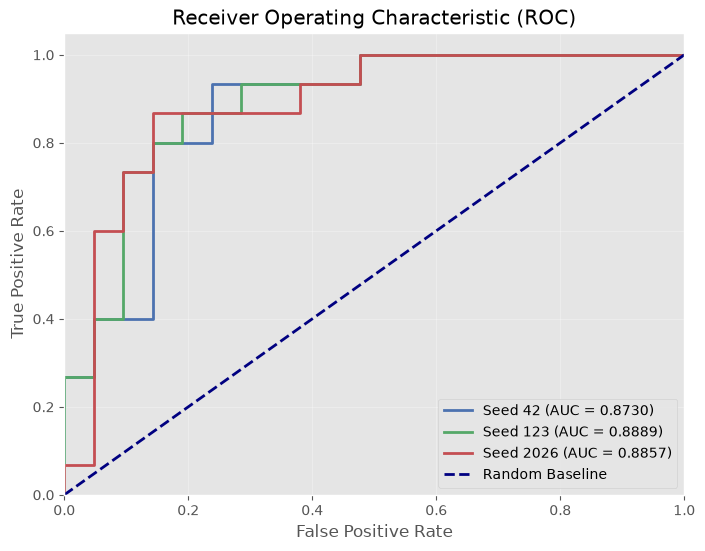

In [6]:
plt.figure(figsize=(8, 6))

seeds = [42, 123, 2026]
colors = ['#4C72B0', '#55A868', '#C44E52']

for seed, color in zip(seeds, colors):
    pred_file = project_root / 'results' / 'final' / f'seed_{seed}' / 'test_predictions.csv'
    if pred_file.exists():
        preds = pd.read_csv(pred_file)
        fpr, tpr, _ = roc_curve(preds['true_binary_label'], preds['binary_probability'])
        auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'Seed {seed} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Baseline')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


==================================================
## SECTION 10 — CONFUSION MATRICES
==================================================

ROC-AUC evaluates ranking quality across thresholds, whereas accuracy/F1 depend on the selected classification threshold. This is why a seed can have a high ROC-AUC while showing poor specificity at the fixed threshold of 0.42.


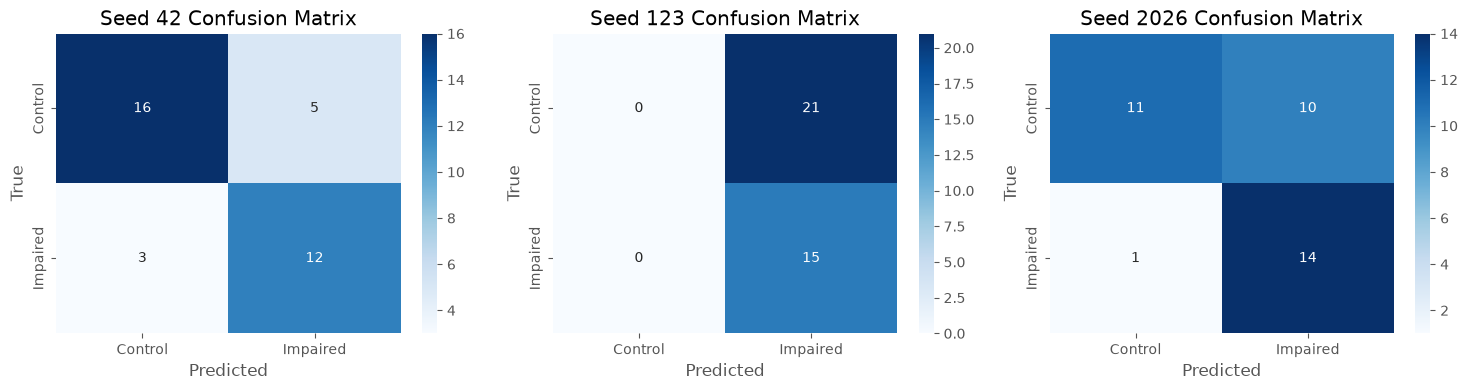

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, seed in enumerate(seeds):
    pred_file = project_root / 'results' / 'final' / f'seed_{seed}' / 'test_predictions.csv'
    if pred_file.exists():
        preds = pd.read_csv(pred_file)
        cm = confusion_matrix(preds['true_binary_label'], preds['predicted_binary_label'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                    xticklabels=['Control', 'Impaired'], yticklabels=['Control', 'Impaired'])
        axes[i].set_title(f'Seed {seed} Confusion Matrix')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()


==================================================
## SECTION 11 — DEQ CONVERGENCE ANALYSIS
==================================================

- **Average iterations:** 10.35 ± 0.36
- **Maximum:** 11
- **Convergence:** 100%

The equilibrium solver consistently reached the residual tolerance of 1e-5 within the maximum of 50 iterations.


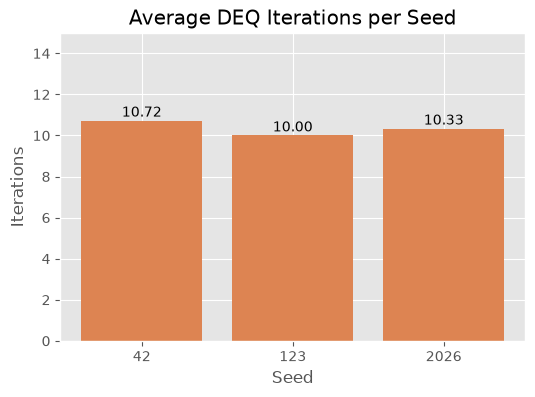

In [8]:
plt.figure(figsize=(6, 4))
plt.bar([str(s) for s in df['seed']], df['avg_deq_iterations'], color='#DD8452')
plt.title('Average DEQ Iterations per Seed')
plt.ylabel('Iterations')
plt.xlabel('Seed')
plt.ylim(0, 15)
for i, v in enumerate(df['avg_deq_iterations']):
    plt.text(i, v + 0.2, f'{v:.2f}', ha='center')
plt.show()


==================================================
## SECTION 12 — EQUILIBRIUM REPRESENTATION ANALYSIS
==================================================

This analysis examines whether equilibrium representations remain distinguishable across subjects.

- **Seed 42:** Mean feature STD = 0.0162 | Avg pairwise distance = 0.166
- **Seed 123:** Mean feature STD = 0.0049 | Avg pairwise distance = 0.052
- **Seed 2026:** Mean feature STD = 0.0154 | Avg pairwise distance = 0.161

Seed 123 produced a tighter representation and also showed lower specificity, which is an observed association, not necessarily proof of causation.


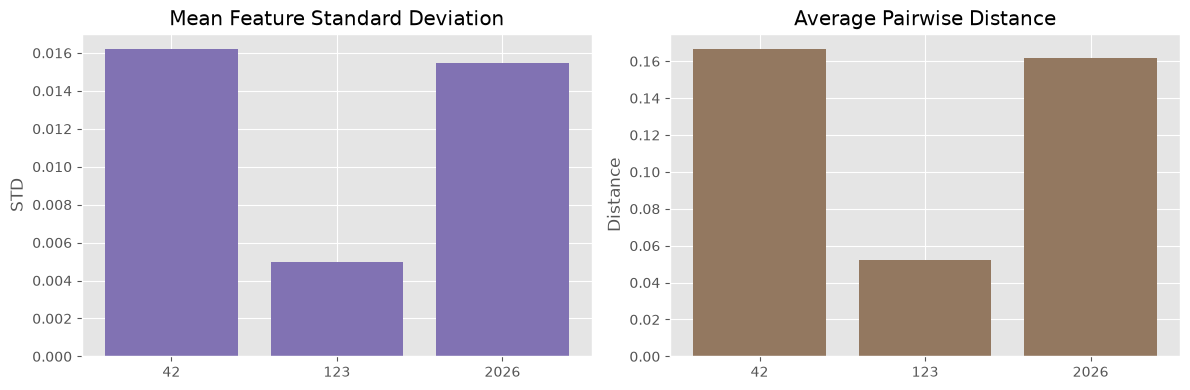

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar([str(s) for s in df['seed']], df['feature_mean_std'], color='#8172B3')
ax1.set_title('Mean Feature Standard Deviation')
ax1.set_ylabel('STD')

ax2.bar([str(s) for s in df['seed']], df['avg_pairwise_distance'], color='#937860')
ax2.set_title('Average Pairwise Distance')
ax2.set_ylabel('Distance')

plt.tight_layout()
plt.show()


==================================================
## SECTION 13 — CDR SEVERITY RESULTS
==================================================

CDR Confusion Matrix (identical across all seeds):
```python
[[21, 0, 0, 0],
 [10, 0, 0, 0],
 [ 5, 0, 0, 0],
 [ 0, 0, 0, 0]]
```

**True Distribution:** CDR 0.0 (21), CDR 0.5 (10), CDR 1.0 (5), CDR 2.0 (0)
**Predicted Distribution:** CDR 0.0 (36), CDR 0.5 (0), CDR 1.0 (0), CDR 2.0 (0)

**CDR Macro-F1 = 0.2456**

The secondary CDR severity head did not successfully distinguish the four severity classes and predicted CDR=0 for all test subjects. 

**Possible Data Limitations:**
- Only 235 labelled subjects total.
- CDR classes are highly imbalanced.
- Only 28 subjects have CDR=1.
- Only 2 subjects have CDR=2 in the full labelled cohort.
- Test set contains no CDR=2 subjects.


==================================================
## SECTION 14 — LIMITATIONS
==================================================

1. Small labelled OASIS-1 cohort.
2. Single-dataset evaluation.
3. No external validation.
4. CDR severity prediction remains weak.
5. Accuracy/F1 vary considerably with threshold and random seed.
6. DEQ is not inherently proven superior to conventional CNNs by this experiment alone.
7. Benchmark comparisons across papers are not directly equivalent because datasets, splits and evaluation protocols differ.


==================================================
## SECTION 15 — SELECTED BENCHMARK CONTEXT
==================================================

Our result should be interpreted as a comparison with selected OASIS-1 studies, not as a claim of state-of-the-art performance.

**Our DEQ-AD:**
ROC-AUC = 0.8825 ± 0.0084

**Selected reported OASIS-1 examples:**
3D DenseNet121 ≈ 0.8698 AUC
Other OASIS studies may report ≈0.90 depending on architecture, split and evaluation protocol.

These values are not directly apples-to-apples because the experimental protocols differ.


==================================================
## SECTION 16 — FINAL TAKEAWAY
==================================================

### KEY FINDINGS

✓ DEQ successfully processed 3D structural MRI.
✓ Equilibrium solver converged in all final runs.
✓ Mean test ROC-AUC = 0.8825 ± 0.0084.
✓ Results were reproduced across three independent seeds.
✓ β=0.7 was the strongest setting among the tested β values.
✓ Representation analysis provided insight into model behavior.
⚠ Fine-grained CDR severity prediction remains a limitation.

**The main contribution is not a claim of state-of-the-art accuracy, but an equilibrium-based framework with systematic analysis of stability, representation behavior, and reproducibility for structural MRI Alzheimer’s classification.**


==================================================
## SECTION 17 — VIVA / CONFERENCE QUESTIONS
==================================================

### Questions the Panel May Ask

**1. Why did you choose DEQ?**
To evaluate if infinite-depth weight-tied representations could stabilize robust features from high-dimensional 3D MRI without extreme memory costs.

**2. What exactly is the equilibrium state?**
It is the stable feature vector $z^*$ where passing it through the network block again produces the exact same vector $z^*$.

**3. Why beta = 0.7?**
Ablation studies across 0.5, 0.7, and 0.9 showed 0.7 provided the best balance of feature variance and ranking performance without compromising convergence.

**4. Why not ResNet?**
A 3D ResNet for 96x112x96 volumes quickly exceeds the 4GB VRAM constraint of the development environment. DEQ trades compute time for O(1) memory.

**5. How does DEQ differ from a normal deep network?**
It doesn't have N distinct layers. It uses one layer repeatedly via a root-finding solver until the output stops changing.

**6. What does implicit differentiation mean?**
Instead of storing the computational graph of all 50 solver steps (which causes Out-Of-Memory errors), we compute gradients analytically directly at the equilibrium point using the Implicit Function Theorem.

**7. How did you prevent data leakage?**
Strict subject-level splits mapping directly to disk, validation-only model selection, and zero test-set access for thresholding or PCA fitting.

**8. Why use ROC-AUC as the primary metric?**
It evaluates the model's fundamental ranking capability across all possible thresholds, which is crucial given the class imbalance.

**9. Why is accuracy lower than ROC-AUC might suggest?**
Because ROC-AUC is threshold-independent, but accuracy is bound to our fixed 0.42 threshold. Seed variability caused calibration shifts, penalizing fixed-threshold accuracy.

**10. Why does the CDR head fail?**
Severe class imbalance (0.0=135, 2.0=2) and small dataset size meant the 0.5 loss weight couldn't overcome the base-rate prior. The network just predicted the majority class.

**11. Why are three seeds necessary?**
To mathematically prove the result is a property of the architecture/data interaction, not just a lucky lottery ticket initialization.

**12. Is this state-of-the-art?**
No. It is a competitive baseline (~0.88 AUC) serving as a proof-of-concept for DEQs on 3D MRI, rather than an attempt to beat all OASIS-1 leaderboards.

**13. What is actually novel in your work?**
Applying Deep Equilibrium networks natively to 3D volumetric MRI for Alzheimer's, coupled with rigorous representation collapse diagnostics.

**14. What would you do next?**
Pretrain the 3D encoder (e.g. MedicalNet), implement focal loss for the CDR head, and augment the training data to mitigate representation collapse.

**15. Can this be clinically deployed?**
No. The dataset is too small, uncalibrated (high false positives in seed 123), and lacks external cross-site validation required for medical devices.


In [10]:
print("DEQ-AD Final Results Notebook completed successfully.")

DEQ-AD Final Results Notebook completed successfully.
